### MTG sélection par celltype

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import anndata as ad
import scanpy as sc
import muon as mu
from muon import atac as ac

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
mpl.rcParams["figure.figsize"] = (6, 5)

print(f"scanpy  {sc.__version__}")
print(f"anndata {ad.__version__}")
print(f"muon    {mu.__version__}")

scanpy  1.9.6
anndata 0.9.2
muon    0.1.5


In [2]:
DATA_PATH = "../data/raw/SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad"

adata = sc.read_h5ad(DATA_PATH)
print(adata)
print("\n--- obs columns ---")
print(adata.obs.columns.tolist())
print("\n--- var columns ---")
print(adata.var.columns.tolist())

AnnData object with n_obs × n_vars = 1123761 × 218882
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in m

In [3]:
# Quick peek at cell metadata and peak names
display(adata.obs.head(3))
display(adata.var.head(3))

# Feature format (e.g. "chr1:1000-2000")
print("\nFirst 5 peak names:", adata.var_names[:5].tolist())

,sample_id,Neurotypical reference,Donor ID,Organism,Brain Region,Sex,Gender,Age at Death,Race (choice=White),Race (choice=Black/ African American),...,Class,Subclass confidence,Subclass,Supertype confidence,Supertype (non-expanded),Supertype,RNA Quality Control Score,Quality Control Clusters,Continuous Pseudo-progression Score,Severely Affected Donor
index,,,,,,,,,,,,,,,,,,,,,
CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124,CTTCTAACACAAGGGT-L8AT_211215_01_G07-1149773124,False,H21.33.025,human,Human MTG,Female,Female,88.0,Checked,Unchecked,...,Neuronal: Glutamatergic,NaN,NaN,NaN,NaN,snATACseq_QC,0.257159,0,0.518005,N
TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228,TGTAAAGCACATTAAC-L8XR_210805_01_H09-1124629228,False,H20.33.025,human,Human MTG,Male,Male,94.0,Checked,Unchecked,...,Neuronal: Glutamatergic,1.0,L4 IT,1.0,L4 IT_2,L4 IT_2,0.000000,2,0.588882,N
TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693,TAGACTGCATCCTGGG-L8AT_210916_01_B08-1131409693,False,H21.33.003,human,Human MTG,Male,Male,78.0,Unchecked,Unchecked,...,Neuronal: Glutamatergic,NaN,NaN,NaN,NaN,snATACseq_QC,0.000000,4,0.238033,N


""
chr4:164130572-164131513
chr4:16412872-16415576
chr4:164116366-164116739



First 5 peak names: ['chr4:164130572-164131513', 'chr4:16412872-16415576', 'chr4:164116366-164116739', 'chr4:164083047-164083256', 'chr4:164056041-164057013']


In [4]:
qc_cols = [
    'ATAC_Median_high_quality_fragments_per_cell',
    'ATAC_TSS_enrichment_score',
    'ATAC_Fraction_of_high_quality_fragments_overlapping_TSS',
    'ATAC_Fraction_of_high_quality_fragments_overlapping_peaks',
    'ATAC_Percent_duplicates',
    'Doublet score',
    'Fraction mitochondrial UMIs',
]

# Conversion en numérique
for col in qc_cols:
    adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')

print("=== Stats descriptives QC ===")
print(adata.obs[qc_cols].describe().round(3))

print("\n=== Used in analysis ===")
print(adata.obs['Used in analysis'].value_counts())


=== Stats descriptives QC ===
       ATAC_Median_high_quality_fragments_per_cell  ATAC_TSS_enrichment_score  \
count                                  1123761.000                1123761.000   
mean                                     39400.636                      4.579   
std                                      19415.343                      0.679   
min                                         18.000                      2.608   
25%                                      26081.000                      4.175   
50%                                      36681.500                      4.577   
75%                                      51241.000                      5.010   
max                                      99374.000                      6.245   

       ATAC_Fraction_of_high_quality_fragments_overlapping_TSS  \
count                                        1123761.000         
mean                                               0.214         
std                                       

In [5]:
print("=== Valeurs manquantes par métrique ===")
for col in qc_cols:
    n_missing = adata.obs[col].isna().sum()
    pct = n_missing / adata.n_obs * 100
    print(f"{col:<55} : {n_missing:>7,} NaN ({pct:.1f}%)")

print("\n=== Lien avec 'Used in analysis' ===")
# Est-ce que les NaN dans Doublet score correspondent aux False ?
mask_used = adata.obs['Used in analysis'] == True
mask_doublet_notna = adata.obs['Doublet score'].notna()
print(f"Used=True    : {mask_used.sum():,}")
print(f"Doublet notna: {mask_doublet_notna.sum():,}")
print(f"Used=True ET Doublet notna: {(mask_used & mask_doublet_notna).sum():,}")


=== Valeurs manquantes par métrique ===
ATAC_Median_high_quality_fragments_per_cell             :       0 NaN (0.0%)
ATAC_TSS_enrichment_score                               :       0 NaN (0.0%)
ATAC_Fraction_of_high_quality_fragments_overlapping_TSS :       0 NaN (0.0%)
ATAC_Fraction_of_high_quality_fragments_overlapping_peaks :       0 NaN (0.0%)
ATAC_Percent_duplicates                                 :       0 NaN (0.0%)
Doublet score                                           : 861,995 NaN (76.7%)
Fraction mitochondrial UMIs                             : 861,995 NaN (76.7%)

=== Lien avec 'Used in analysis' ===
Used=True    : 0
Doublet notna: 261,766
Used=True ET Doublet notna: 0


In [6]:
# Vérification du type
print("Type de 'Used in analysis':", adata.obs['Used in analysis'].dtype)
print("Valeurs uniques:", adata.obs['Used in analysis'].unique()[:5])

# Correction : comparaison avec string
mask_used = adata.obs['Used in analysis'].astype(str) == 'True'
mask_doublet_notna = adata.obs['Doublet score'].notna()

print(f"\nUsed=True                 : {mask_used.sum():,}")
print(f"Doublet notna             : {mask_doublet_notna.sum():,}")
print(f"Used=True ET Doublet notna: {(mask_used & mask_doublet_notna).sum():,}")
print(f"Used=True ET Doublet NaN  : {(mask_used & ~mask_doublet_notna).sum():,}")


Type de 'Used in analysis': category
Valeurs uniques: ['False', 'True']
Categories (2, object): ['False', 'True']

Used=True                 : 516,389
Doublet notna             : 261,766
Used=True ET Doublet notna: 138,118
Used=True ET Doublet NaN  : 378,271


In [7]:
# Filtrage sur les noyaux validés par SEA-AD
adata_used = adata[adata.obs['Used in analysis'].astype(str) == 'True'].copy()

print(f"Noyaux retenus : {adata_used.n_obs:,} / {adata.n_obs:,}")
print(f"Donors uniques : {adata_used.obs['Donor ID'].nunique()}")
print(f"Subclasses     : {adata_used.obs['Subclass'].nunique()}")


Noyaux retenus : 516,389 / 1,123,761
Donors uniques : 86
Subclasses     : 24


In [8]:
adata.obs['log10_fragments'] = np.log10(
    adata.obs['ATAC_Median_high_quality_fragments_per_cell'] + 1
)
adata.obs['tss_score']  = adata.obs['ATAC_TSS_enrichment_score']
adata.obs['frac_peaks'] = adata.obs['ATAC_Fraction_of_high_quality_fragments_overlapping_peaks']
adata.obs['frac_tss']   = adata.obs['ATAC_Fraction_of_high_quality_fragments_overlapping_TSS']
adata.obs['pct_dup']    = adata.obs['ATAC_Percent_duplicates']



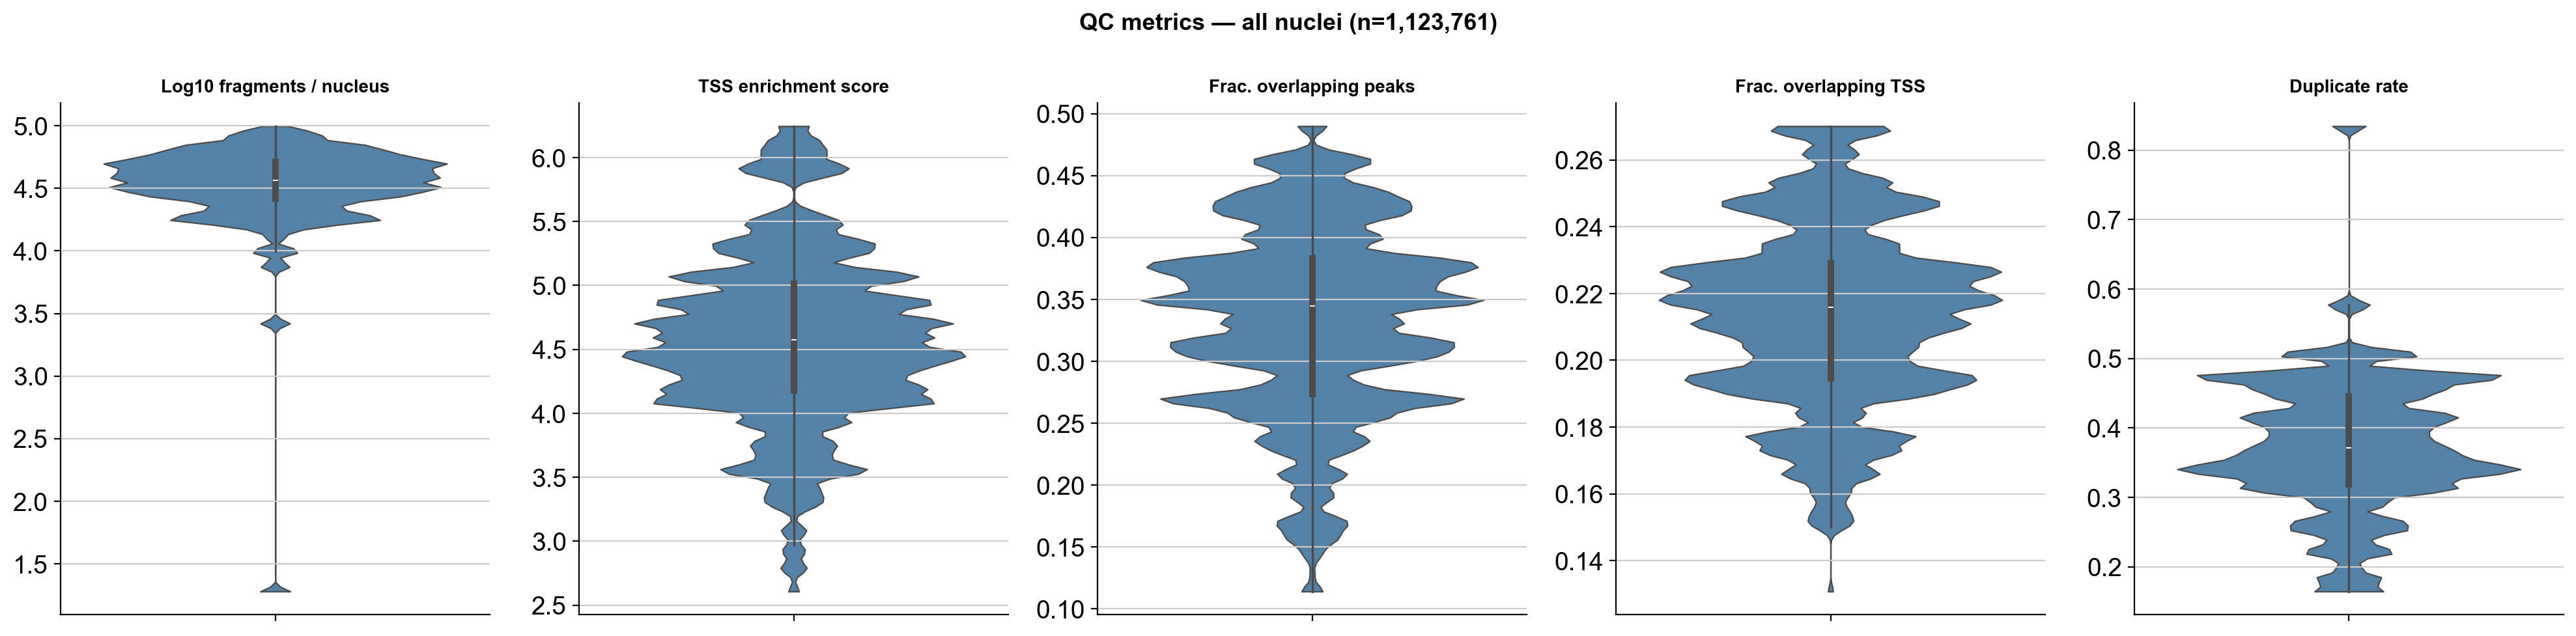

In [9]:
qc_metrics = {
    'log10_fragments' : 'Log10 fragments / nucleus',
    'tss_score'       : 'TSS enrichment score',
    'frac_peaks'      : 'Frac. overlapping peaks',
    'frac_tss'        : 'Frac. overlapping TSS',
    'pct_dup'         : 'Duplicate rate',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('QC metrics — all nuclei (n=1,123,761)', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, qc_metrics.items()):
    sns.violinplot(
        data=adata.obs, y=col, ax=ax,
        color='steelblue', inner='box',
        cut=0, linewidth=0.8
    )
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


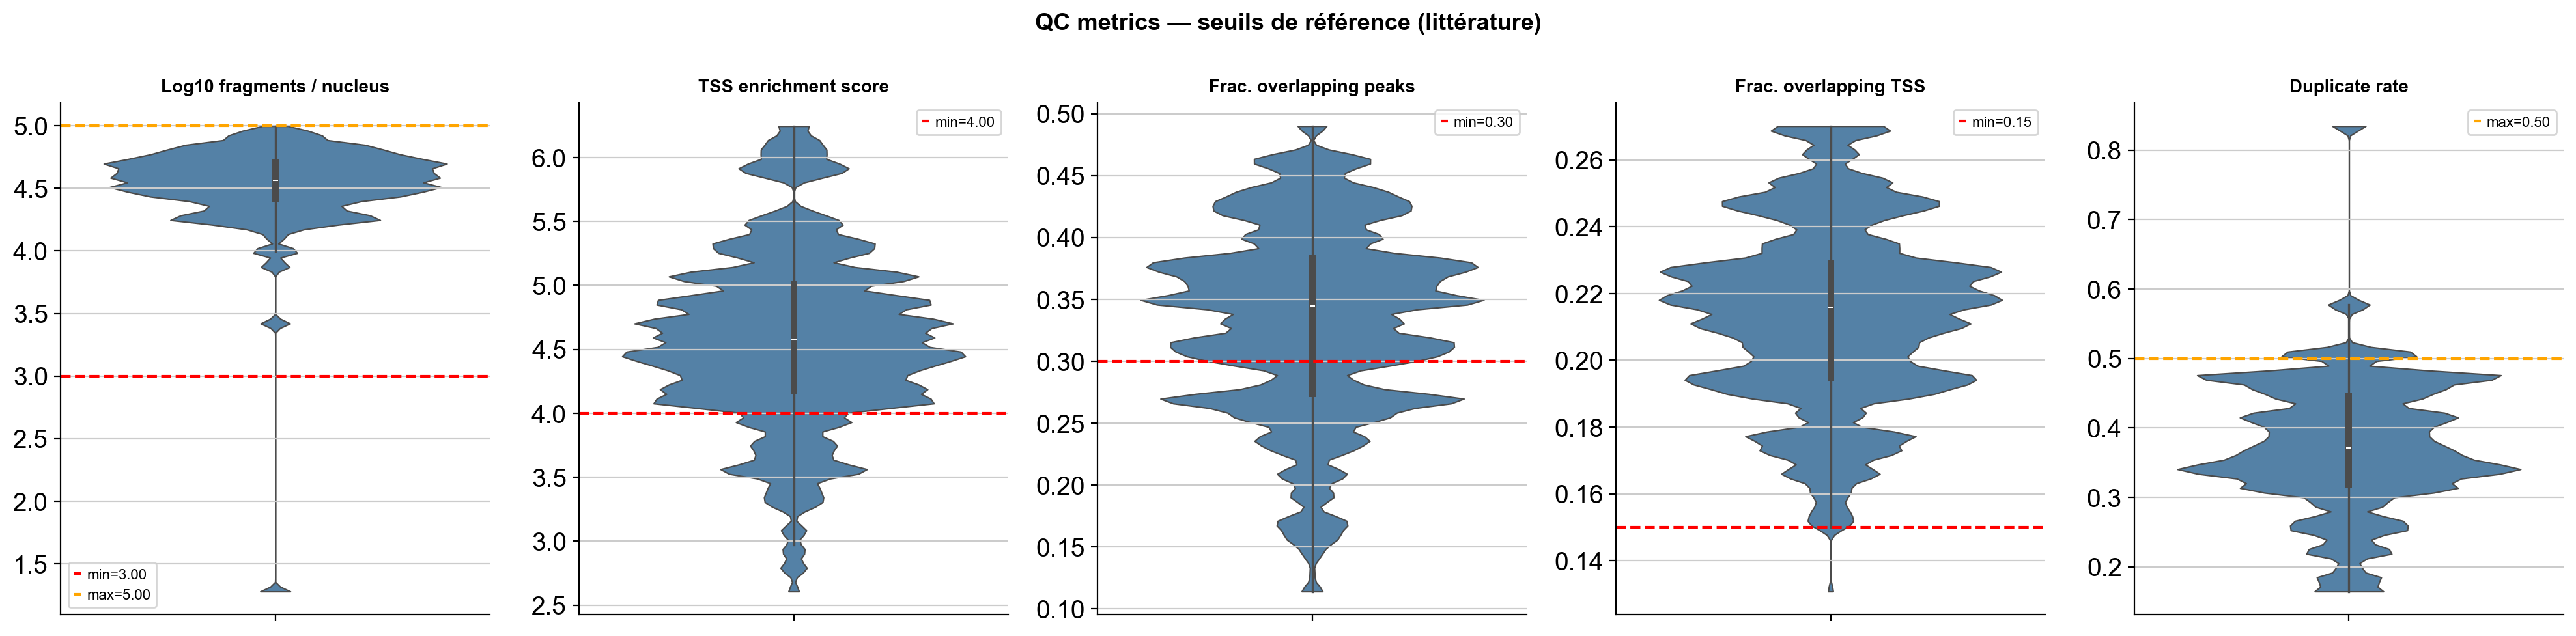

In [10]:
# Seuils standards snATAC-seq (littérature)
thresholds = {
    'log10_fragments' : {'min': np.log10(1000), 'max': np.log10(100000)},
    'tss_score'       : {'min': 4,    'max': None},
    'frac_peaks'      : {'min': 0.3, 'max': None},
    'frac_tss'        : {'min': 0.15, 'max': None},
    'pct_dup'         : {'min': None, 'max': 0.5},
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('QC metrics — seuils de référence (littérature)', fontsize=13, fontweight='bold')

labels = {
    'log10_fragments' : 'Log10 fragments / nucleus',
    'tss_score'       : 'TSS enrichment score',
    'frac_peaks'      : 'Frac. overlapping peaks',
    'frac_tss'        : 'Frac. overlapping TSS',
    'pct_dup'         : 'Duplicate rate',
}

for ax, col in zip(axes, thresholds.keys()):
    sns.violinplot(
        data=adata.obs, y=col, ax=ax,
        color='steelblue', inner='box',
        cut=0, linewidth=0.8
    )
    # Ligne min en rouge
    if thresholds[col]['min'] is not None:
        ax.axhline(thresholds[col]['min'], color='red', linestyle='--', 
                   linewidth=1.5, label=f"min={thresholds[col]['min']:.2f}")
    # Ligne max en orange
    if thresholds[col]['max'] is not None:
        ax.axhline(thresholds[col]['max'], color='orange', linestyle='--', 
                   linewidth=1.5, label=f"max={thresholds[col]['max']:.2f}")
    
    ax.set_title(labels[col], fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


In [11]:
seuils = {
    'log10_fragments' : ('min', np.log10(1000)),
    'tss_score'       : ('min', 4.0),
    'frac_peaks'      : ('min', 0.3),
    'frac_tss'        : ('min', 0.15),
    'pct_dup'         : ('max', 0.50),
}

print(f"Total noyaux de départ : {adata.n_obs:,}\n")
mask_keep = pd.Series(True, index=adata.obs_names)

for col, (direction, val) in seuils.items():
    vals = adata.obs[col]
    if direction == 'min':
        crit = vals >= val
    else:
        crit = vals <= val

    # NaN comptés comme échec du critère
    crit = crit.fillna(False)
    n_fail = (~crit).sum()
    pct = n_fail / adata.n_obs * 100
    print(f"{col:<20} {direction}={val:.2f} → exclut {n_fail:>7,} noyaux ({pct:.1f}%)")

    mask_keep &= crit

n_keep = int(mask_keep.sum())
n_excl = adata.n_obs - n_keep
print("\n--- Filtre combiné (tous les seuils) ---")
print(f"Noyaux restants : {n_keep:,} / {adata.n_obs:,} ({n_keep/adata.n_obs*100:.1f}%)")
print(f"Noyaux exclus   : {n_excl:,} ({n_excl/adata.n_obs*100:.1f}%)")
print(f'{adata_used.n_obs}  # {n_keep:,} noyaux retenus')

Total noyaux de départ : 1,123,761

log10_fragments      min=3.00 → exclut  11,307 noyaux (1.0%)
tss_score            min=4.00 → exclut 181,280 noyaux (16.1%)
frac_peaks           min=0.30 → exclut 345,242 noyaux (30.7%)
frac_tss             min=0.15 → exclut   1,314 noyaux (0.1%)
pct_dup              max=0.50 → exclut  79,723 noyaux (7.1%)

--- Filtre combiné (tous les seuils) ---
Noyaux restants : 696,097 / 1,123,761 (61.9%)
Noyaux exclus   : 427,664 (38.1%)
516389  # 696,097 noyaux retenus


In [12]:
# Appliquer le masque QC
adata_qc = adata[mask_keep].copy()
print(f"Après QC : {adata_qc.n_obs:,} noyaux")

# Sélectionner les neurones
neuron_classes = ['Neuronal: Glutamatergic', 'Neuronal: GABAergic']
mask_neurons = adata_qc.obs['Class'].isin(neuron_classes)
adata_neurons = adata_qc[mask_neurons].copy()

print(f"\nAprès sélection neurones :")
print(f"  Total    : {adata_neurons.n_obs:,}")
print(adata_neurons.obs['Class'].value_counts())
print(f"\nDonors uniques : {adata_neurons.obs['Donor ID'].nunique()}")


Après QC : 696,097 noyaux

Après sélection neurones :
  Total    : 615,730
Class
Neuronal: Glutamatergic    491452
Neuronal: GABAergic        124278
Name: count, dtype: int64

Donors uniques : 62


nombre de donors : 62
Noyaux par donor :
  Min     : 3,822
  Médiane : 7,818
  Max     : 25,444
  Donors < 500 noyaux  : 0
  Donors < 1000 noyaux : 0


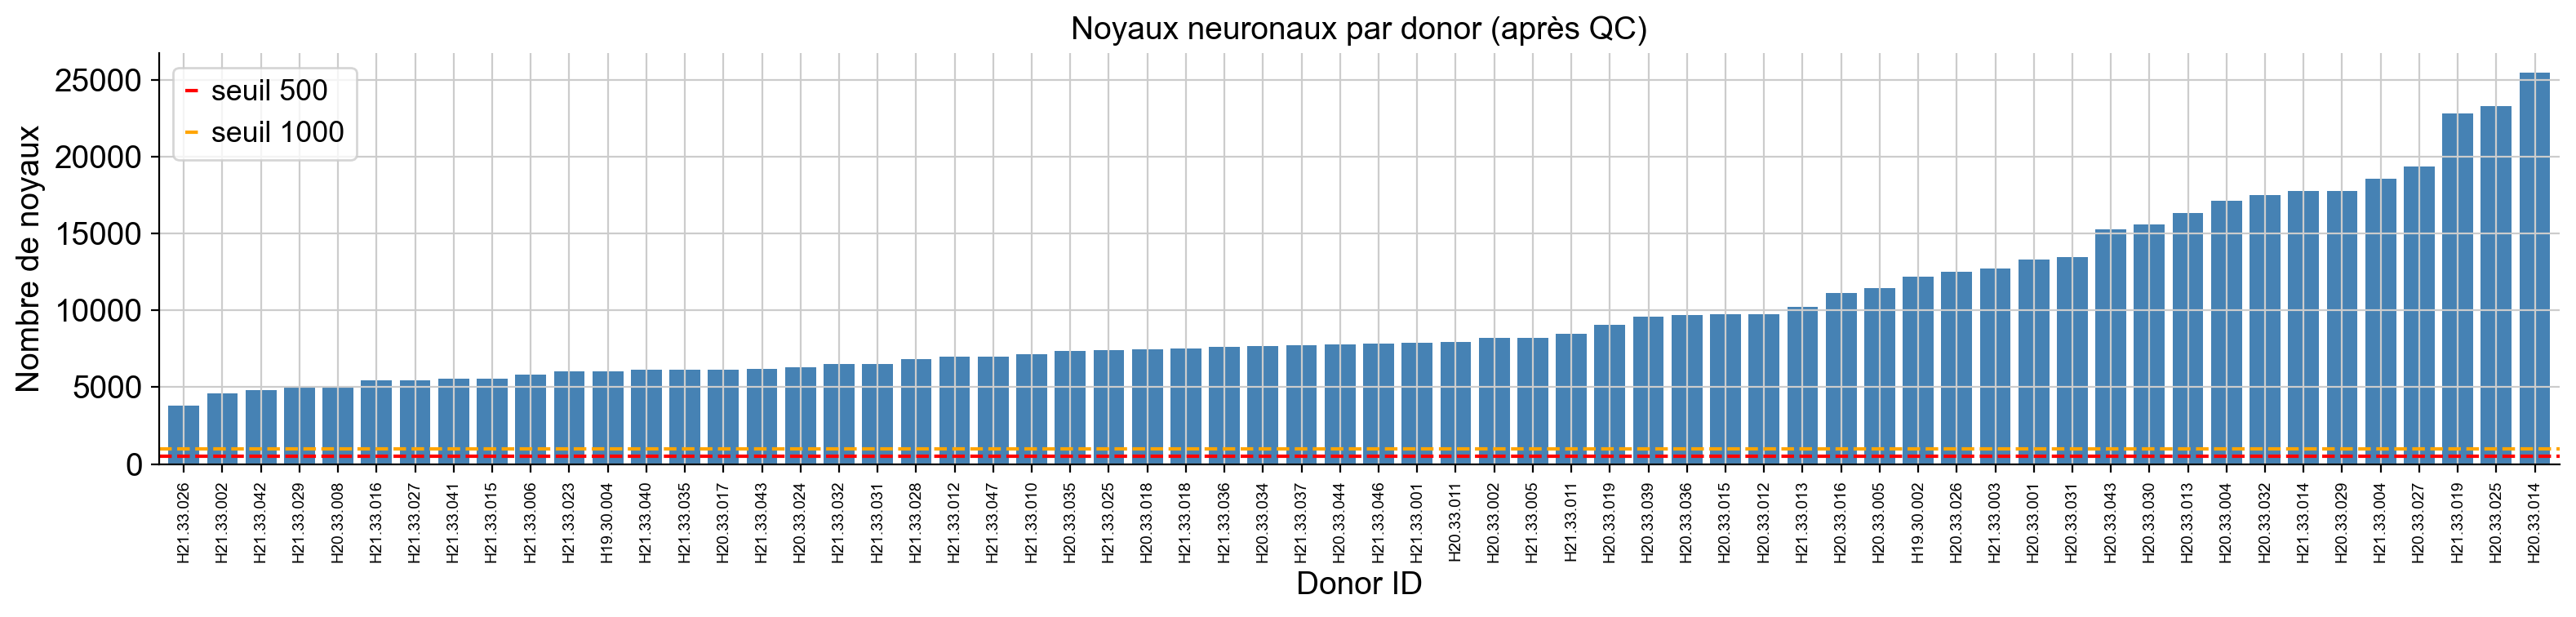

In [13]:
nuclei_per_donor = adata_neurons.obs.groupby('Donor ID').size().sort_values()
print(f"nombre de donors : {nuclei_per_donor.size}")
print("Noyaux par donor :")
print(f"  Min     : {nuclei_per_donor.min():,}")
print(f"  Médiane : {nuclei_per_donor.median():,.0f}")
print(f"  Max     : {nuclei_per_donor.max():,}")
print(f"  Donors < 500 noyaux  : {(nuclei_per_donor < 500).sum()}")
print(f"  Donors < 1000 noyaux : {(nuclei_per_donor < 1000).sum()}")

fig, ax = plt.subplots(figsize=(16, 4))
nuclei_per_donor.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.axhline(500,  color='red',    linestyle='--', linewidth=1.5, label='seuil 500')
ax.axhline(1000, color='orange', linestyle='--', linewidth=1.5, label='seuil 1000')
ax.set_xlabel('Donor ID')
ax.set_ylabel('Nombre de noyaux')
ax.set_title('Noyaux neuronaux par donor (après QC)')
ax.legend()
ax.set_xticklabels(nuclei_per_donor.index, rotation=90, fontsize=7)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('qc_03_nuclei_per_donor.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Une ligne par donor avec ses covariables cliniques
donor_meta = adata_neurons.obs.groupby('Donor ID').first()[[
    'Cognitive Status', 
    'Braak', 
    'CERAD score',
    'Overall AD neuropathological Change',
    'Continuous Pseudo-progression Score',
    'Sex',
    'Age at Death',
]].copy()

# Conversion numérique
donor_meta['Pseudo_score'] = pd.to_numeric(
    donor_meta['Continuous Pseudo-progression Score'], errors='coerce'
)
donor_meta['Braak_num'] = pd.to_numeric(donor_meta['Braak'], errors='coerce')

print("=== Distribution Cognitive Status ===")
print(donor_meta['Cognitive Status'].value_counts())

print("\n=== Pseudo-progression Score ===")
print(donor_meta['Pseudo_score'].describe().round(3))

print("\n=== Sex ===")
print(donor_meta['Sex'].value_counts())



=== Distribution Cognitive Status ===
Cognitive Status
No dementia    37
Dementia       23
Reference       2
Name: count, dtype: int64

=== Pseudo-progression Score ===
count    60.000
mean      0.576
std       0.243
min       0.150
25%       0.351
50%       0.621
75%       0.787
max       0.910
Name: Pseudo_score, dtype: float64

=== Sex ===
Sex
Female    34
Male      28
Name: count, dtype: int64


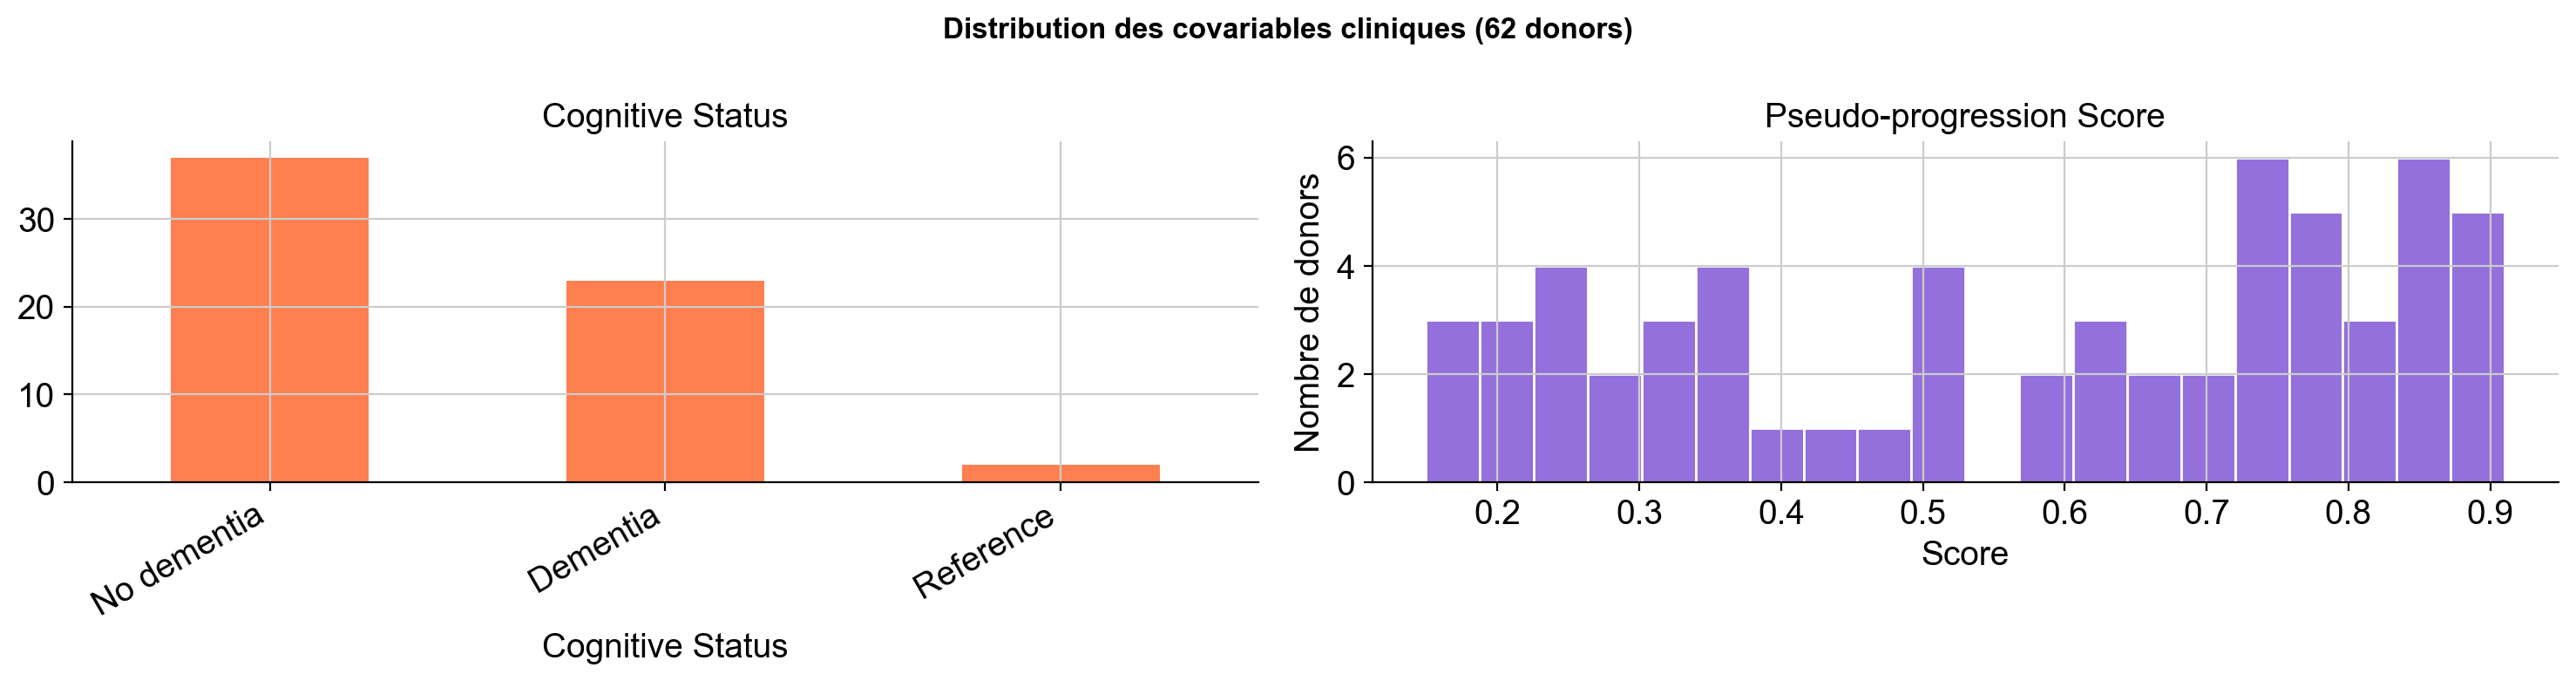

In [15]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Distribution des covariables cliniques (62 donors)', 
             fontsize=12, fontweight='bold')

donor_meta['Cognitive Status'].value_counts().plot(
    kind='bar', ax=axes[0], color='coral'
)
axes[0].set_title('Cognitive Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
sns.despine(ax=axes[0])

axes[1].hist(donor_meta['Pseudo_score'].dropna(), bins=20, color='mediumpurple', edgecolor='white')
axes[1].set_title('Pseudo-progression Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Nombre de donors')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [16]:
import scipy.sparse as sp

# Somme des counts par donor
donors = adata_neurons.obs['Donor ID'].unique()
print(f"Construction du pseudobulk pour {len(donors)} donors...")

# Matrice pseudobulk : donors × peaks
pb_matrix = []
for donor in donors:
    mask = adata_neurons.obs['Donor ID'] == donor
    donor_counts = adata_neurons[mask].X
    # Somme sur tous les noyaux du donor
    if sp.issparse(donor_counts):
        pb_matrix.append(np.array(donor_counts.sum(axis=0)).flatten())
    else:
        pb_matrix.append(donor_counts.sum(axis=0))

pb_matrix = np.array(pb_matrix)  # shape : (62, 218882)
print(f"Matrice pseudobulk : {pb_matrix.shape}")
print(f"  → {pb_matrix.shape[0]} donors × {pb_matrix.shape[1]:,} peaks")
print(f"Counts totaux min/max par donor : {pb_matrix.sum(axis=1).min():,.0f} / {pb_matrix.sum(axis=1).max():,.0f}")


Construction du pseudobulk pour 62 donors...


Matrice pseudobulk : (62, 218882)
  → 62 donors × 218,882 peaks
Counts totaux min/max par donor : 192,758,736 / 1,398,978,944


In [17]:
donor_meta = adata_neurons.obs.groupby('Donor ID').first()[[
    'Sex',
    'Age at Death',
    'PMI',
    'Brain pH',
    'Cognitive Status',
    'Continuous Pseudo-progression Score',
    'APOE Genotype',
]].copy()

donor_meta = donor_meta.loc[donors]

for col in ['Age at Death', 'PMI', 'Brain pH', 'Continuous Pseudo-progression Score']:
    donor_meta[col] = pd.to_numeric(donor_meta[col], errors='coerce')

adata_pb = ad.AnnData(
    X=pb_matrix,
    obs=donor_meta,
    var=adata_neurons.var.copy(),
)
adata_pb.obs_names = donors

print(adata_pb)
print("\n=== Covariables numériques ===")
print(donor_meta[['Age at Death', 'PMI', 'Brain pH',
                   'Continuous Pseudo-progression Score']].describe().round(2))


AnnData object with n_obs × n_vars = 62 × 218882
    obs: 'Sex', 'Age at Death', 'PMI', 'Brain pH', 'Cognitive Status', 'Continuous Pseudo-progression Score', 'APOE Genotype'

=== Covariables numériques ===
       Age at Death    PMI  Brain pH  Continuous Pseudo-progression Score
count         60.00  60.00     60.00                                60.00
mean          89.52   7.04      6.74                                 0.58
std            7.75   2.33      0.32                                 0.24
min           69.00   3.20      6.40                                 0.15
25%           85.00   4.78      6.40                                 0.35
50%           91.00   7.00      6.75                                 0.62
75%           95.00   8.98      6.80                                 0.79
max          102.00  11.42      7.60                                 0.91


In [18]:
# count_matrix.txt : peaks × donors (transposé)
pb_df = pd.DataFrame(
    adata_pb.X.T,                    # transposer → peaks × donors
    index=adata_neurons.var_names,   # noms des peaks en lignes
    columns=adata_pb.obs_names       # donor IDs en colonnes
).astype(int)

pb_df.to_csv('../data/processed/count_matrix.txt', sep='\t')
print(f"count_matrix.txt : {pb_df.shape[0]:,} peaks × {pb_df.shape[1]} donors")
print(pb_df.iloc[:5, :5])  # aperçu

# metadata.txt : donors × covariables
meta_df = adata_pb.obs.copy()
meta_df.index.name = 'Sample'
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print(f"\nmetadata.txt : {meta_df.shape[0]} donors × {meta_df.shape[1]} colonnes")
print(meta_df.head(3))


count_matrix.txt : 218,882 peaks × 62 donors
                          H21.33.025  H20.33.025  H21.33.003  H21.33.019  \
chr4:164130572-164131513        1253        2219        1470        2512   
chr4:16412872-16415576          4047        9520        4793        8035   
chr4:164116366-164116739         453         605         520         662   
chr4:164083047-164083256         219         417         263         326   
chr4:164056041-164057013        1252        1142        1053        1879   

                          H20.33.004  
chr4:164130572-164131513        1461  
chr4:16412872-16415576          5887  
chr4:164116366-164116739         281  
chr4:164083047-164083256         275  
chr4:164056041-164057013        1222  

metadata.txt : 62 donors × 7 colonnes
               Sex  Age at Death   PMI  Brain pH Cognitive Status  \
Sample                                                              
H21.33.025  Female          88.0   8.6       6.4      No dementia   
H20.33.025    Male

In [19]:
# Encoder Sex en numérique
meta_df['Sex'] = meta_df['Sex'].map({'Female': 0, 'Male': 1})
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print("\nmetadata.txt mis à jour")
print(meta_df.head(3))


metadata.txt mis à jour
           Sex  Age at Death   PMI  Brain pH Cognitive Status  \
Sample                                                          
H21.33.025   0          88.0   8.6       6.4      No dementia   
H20.33.025   1          94.0   4.5       7.4      No dementia   
H21.33.003   1          78.0  10.0       6.4      No dementia   

            Continuous Pseudo-progression Score APOE Genotype  
Sample                                                         
H21.33.025                             0.518005           3/3  
H20.33.025                             0.588882           3/3  
H21.33.003                             0.238033           3/3  


In [ ]:
def peak_sort_key(peak):
    chrom, coords = peak.split(':')
    start = int(coords.split('-')[0])
    c = chrom.replace('chr', '')
    chrom_num = int(c) if c.isdigit() else {'X': 23, 'Y': 24, 'M': 25}.get(c, 99)
    return (chrom_num, start)

sorted_idx = sorted(pb_df.index.tolist(), key=peak_sort_key)
pb_df = pb_df.loc[sorted_idx]
pb_df.to_csv('../data/processed/count_matrix.txt', sep='\t')
print(pb_df.index[:5].tolist())

['chr1:180742-181572', 'chr1:190803-191893', 'chr1:267958-268038', 'chr1:605375-605629', 'chr1:629906-629979']


In [21]:
meta_df.columns = meta_df.columns.str.replace(' ', '_')
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print(meta_df.columns.tolist())


['Sex', 'Age_at_Death', 'PMI', 'Brain_pH', 'Cognitive_Status', 'Continuous_Pseudo-progression_Score', 'APOE_Genotype']


In [3]:
import pandas as pd

data = pd.read_csv('../data/processed/count_matrix.txt', sep='\t', index_col=0)
data

,H21.33.025,H20.33.025,H21.33.003,H21.33.019,H20.33.004,H21.33.013,H20.33.029,H20.33.039,H20.33.026,H20.33.014,...,H20.33.035,H21.33.027,H20.33.008,H20.33.017,H21.33.028,H21.33.016,H20.33.034,H21.33.041,H21.33.002,H21.33.015
chr1:180742-181572,622,3039,701,1753,1066,456,446,1267,153,4151,...,1011,518,465,321,300,273,923,267,314,474
chr1:190803-191893,2509,3683,5921,2199,3850,1879,2121,2939,1425,6220,...,2830,3165,1519,2359,1073,1345,4249,1304,2384,1298
chr1:267958-268038,123,525,302,307,296,106,194,215,77,344,...,212,359,93,88,135,95,286,55,104,123
chr1:605375-605629,240,1129,388,1086,10,321,227,260,246,380,...,33,439,183,177,296,186,383,172,91,81
chr1:629906-629979,891,1493,949,1398,468,682,334,1,829,879,...,401,362,1153,964,893,215,383,160,260,151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY:56857368-56859198,1102,1359,694,1365,998,1000,297,807,632,1333,...,660,638,713,378,779,342,518,246,336,359
chrY:56860388-56863685,1279,1706,796,1833,1384,1320,449,1019,706,1581,...,763,834,902,450,1026,523,626,330,430,539
chrY:56866375-56867982,479,759,379,977,591,549,225,458,357,672,...,380,353,502,202,559,247,272,158,192,248
chrY:56868658-56875078,3048,4015,1991,4302,3395,2896,1006,2541,1764,3925,...,1601,2058,2102,1200,2504,1039,1484,812,1070,1245


In [5]:
metadata = pd.read_csv('../data/metadata/metadata.txt', sep='\t', index_col=0)

In [7]:
cm_samples = set(data.columns.tolist())
meta_samples = set(metadata.index.tolist())

print("Intersection :", len(cm_samples & meta_samples))
print("Exemple count_matrix :", repr(data.columns[0]))
print("Exemple metadata     :", repr(metadata.index[0]))


Intersection : 59
Exemple count_matrix : '    H21.33.025'
Exemple metadata     : 'H21.33.025'


In [8]:
# Nommer explicitement l'index pour éviter le tab vide en tête
data.index.name = 'peak_id'
data.to_csv('../data/processed/count_matrix.txt', sep='\t')

# Vérifier le résultat
import subprocess
result = subprocess.run(
    ['head', '-1', '../data/processed/count_matrix.txt'],
    capture_output=True, text=True
)
print(result.stdout[:100])


peak_id	    H21.33.025	H20.33.025	H21.33.003	H21.33.019	H20.33.004	H21.33.013	H20.33.029	H20.33.039	


In [9]:
# 1. Supprimer les 2 références (metadata all-NaN)
refs = ['H19.30.002', 'H19.30.004']  # adapte si différent
pb_df = data.drop(columns=[r for r in refs if r in data.columns])

# 2. Repasser en entiers
pb_df = pb_df.astype(int)

# 3. Exporter SANS nommer l'index (tab vide en tête = format attendu par R)
pb_df.index.name = None
pb_df.to_csv('../data/processed/count_matrix.txt', sep='\t')

# Vérification
import subprocess
print(subprocess.run(['head', '-1', '../data/processed/count_matrix.txt'], capture_output=True, text=True).stdout[:80])
print(f"Shape : {pb_df.shape}")
print(f"Dtype : {pb_df.dtypes[0]}")


	    H21.33.025	H20.33.025	H21.33.003	H21.33.019	H20.33.004	H21.33.013	H20.33.02
Shape : (218882, 60)
Dtype : int64


/tmp/ipykernel_2166821/2273472972.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Dtype : {pb_df.dtypes[0]}")


In [12]:
metadata = pd.read_csv('../data/metadata/metadata.txt', sep='\t', index_col=0)
print(metadata["Sex"].value_counts())

Sex
0    34
1    26
Name: count, dtype: int64
